In [145]:
## Graphing for drawing graphs on the evaluated data using evaluate.csv
## Need to query a evaluate.csv file which has around 27,000 records
## Responsible for creating the graphs in the results sections which inclue
##      - 2 bar graphs, 3 visualization, and line graph

In [146]:
import json, cv2, copy

import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from typing import List, Tuple

from microlane.schemas.evaluation import PredictionFile
from microlane.schemas.prediction import Prediction
from microlane.schemas.sample import Sample
from scripts.core.read_image import read_image
from scripts.core.search_evaluation import search_records
from microlane.augmentation.augmentor import Augmentor

In [147]:
def load_results(csv_path: str) -> pd.DataFrame:
    """Load evaluation results CSV and print a quick summary."""

    df = pd.read_csv(csv_path)

    print(f'Loaded {len(df):,} rows  ×  {df.shape[1]} columns')
    return df


df = load_results('/home/suyog/desktop/projects/microlane/results/experiment/evaluate.csv')
df.head(5)

Loaded 27,000 rows  ×  11 columns


,experiment_number,dataset,model,augmentation,raw_file,processed_samples,run_time,accuracy,IOU,fn,fp
0,1,tusimple,ufld,lighting_d,/home/suyog/assets/datasets/TuSimple/TUSimple/...,/home/suyog/assets/datasets/TuSimple/TUSimple/...,0.018957,0.910714,0.440472,0.000000,0.250000
1,2,tusimple,ufld,lighting_d,/home/suyog/assets/datasets/TuSimple/TUSimple/...,/home/suyog/assets/datasets/TuSimple/TUSimple/...,0.004947,0.843750,0.943784,0.000000,0.250000
2,3,tusimple,ufld,lighting_d,/home/suyog/assets/datasets/TuSimple/TUSimple/...,/home/suyog/assets/datasets/TuSimple/TUSimple/...,0.004942,0.575893,0.957459,0.000000,0.500000
3,4,tusimple,ufld,lighting_d,/home/suyog/assets/datasets/TuSimple/TUSimple/...,/home/suyog/assets/datasets/TuSimple/TUSimple/...,0.006487,0.892857,0.954242,0.333333,0.333333
4,5,tusimple,ufld,lighting_d,/home/suyog/assets/datasets/TuSimple/TUSimple/...,/home/suyog/assets/datasets/TuSimple/TUSimple/...,0.005183,0.922619,0.970907,0.000000,0.000000


In [148]:
def collect_records(
    df:           pd.DataFrame,
    datasets:     list[str],
    models:       list[str],
    augmentations: list[str],
) -> list:

    records = []

    for dataset in datasets:
        for model in models:
            for augmentation in augmentations:
                records.append(
                    search_records(df, dataset=dataset, model=model, augmentation=augmentation)
                )

    return records

# DATASETS = ["tusimple", "modified_microlane", "microlane"]
# MODELS = ["ufld", "lanenet", "rld_a", "rld_b "]
# AUGMENTATIONS = ["normal", "motion_blur", "camera_shake", "lighting_b", "lighting_d"]

DATASETS     = ["tusimple", "modified_microlane", "microlane"]
MODELS       = ["rld_b"]
AUGMENTATIONS = ["normal", "motion_blur", "camera_shake", "lighting_b", "lighting_d"]

total_records = collect_records(df, DATASETS, MODELS, AUGMENTATIONS)

In [149]:
def calucalte_metrics(record: pd.DataFrame) -> Tuple[float, float, float, float, float]:
    
    average_accuracy = record["accuracy"].mean()
    
    average_IOU = record["IOU"].mean()
    
    average_run_time= record["run_time"].mean()

    average_fn = record["fn"].mean()

    average_fp = record["fp"].mean()
    
    return ( average_accuracy, average_IOU, average_run_time, average_fn, average_fp)

In [150]:
def calcuate_for_dataset(dataset: str, models: list[str], augmentations: list[str], records: list) -> dict:

    categories = {}

    for record in records:

        record_dataset = record.iloc[0]["dataset"]
        
        record_augmentation = record.iloc[0]["augmentation"]
        
        record_model = record.iloc[0]["model"]

        if record_dataset == dataset:
            
            if len(models) == 1:

                if record_model == models[0]:

                    categories[record_augmentation] = calucalte_metrics(record)

            elif len(augmentations) == 1:

                if record_augmentation == augmentations[0]:

                    categories[record_model] = calucalte_metrics(record)

            else:
                raise ValueError("Wrong Inputs", record_dataset, dataset, len(models), len(augmentations))

    return categories

In [151]:
# Accuracy and IOU in Separate Graphs

def bar_graph(datasets: list[str], models: list[str], augmentations: list[str], records: list):
    
    metrics = []

    for dataset in datasets:
        
        metrics.append(calcuate_for_dataset(dataset, models, augmentations, records))
        
    categories = list(metrics[0].keys())

    metric_idx = 1
    
    metric_name = ["Accuracy", "IOU"][metric_idx]
    
    n_datasets  = len(datasets)

    n_categories = len(categories)

    x = np.arange(n_datasets)

    width = 0.8 / n_categories
    
    
    fig, ax = plt.subplots(figsize=(10, 5))

    for i, cat in enumerate(categories):

        values = [metrics[d][cat][metric_idx] for d in range(n_datasets)]

        offset = (i - (n_categories - 1) / 2) * width

        bars = ax.bar(x + offset, values, width, label=cat)

        for bar in bars:
            h = bar.get_height()

            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,

                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)

    dataset_labels = [d.replace("_", " ").title() for d in datasets]

    ax.set_xticks(x)

    ax.set_xticklabels(dataset_labels)

    ax.set_ylabel(metric_name)

    ax.set_ylim(0, 1.05)

    ax.legend()

    ax.grid(axis='y', linestyle='--', alpha=0.5)

    ax.set_title(
        f"Model Comparison — {augmentations[0]}" if len(augmentations) == 1

        else f"Augmentation Comparison — {models[0]}"

    )

    plt.tight_layout()

    plt.show()

In [152]:
# Accuracy and IOU in a Single Graph

def bar_graph(datasets: list[str], models: list[str], augmentations: list[str], records: list):

    metrics = []

    for dataset in datasets:
        
        metrics.append(calcuate_for_dataset(dataset, models, augmentations, records))


    categories   = list(metrics[0].keys())

    n_datasets   = len(datasets)
    
    n_categories = len(categories)


    x     = np.arange(n_datasets)
    width = 0.8 / n_categories

    dataset_labels = [d.replace("_", " ").title() for d in datasets]

    title = (
        f"Model Comparison — {augmentations[0]}"   if len(augmentations) == 1
        else f"Augmentation Comparison — {models[0]}"
    )


    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title)


    for metric_idx, (ax, metric_name) in enumerate(zip(axes, ["Accuracy", "IOU"])):

        for i, cat in enumerate(categories):

            values = [metrics[d][cat][metric_idx] for d in range(n_datasets)]

            offset = (i - (n_categories - 1) / 2) * width

            bars = ax.bar(x + offset, values, width, label=cat)

            for bar in bars:

                h = bar.get_height()

                ax.text(
                    bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7
                )

        ax.set_xticks(x)

        ax.set_xticklabels(dataset_labels)

        ax.set_ylabel(metric_name)

        ax.set_ylim(0, 1.05)

        ax.set_title(metric_name)

        ax.legend()
        
        ax.grid(axis='y', linestyle='--', alpha=0.5)


    plt.tight_layout()
    
    plt.show()

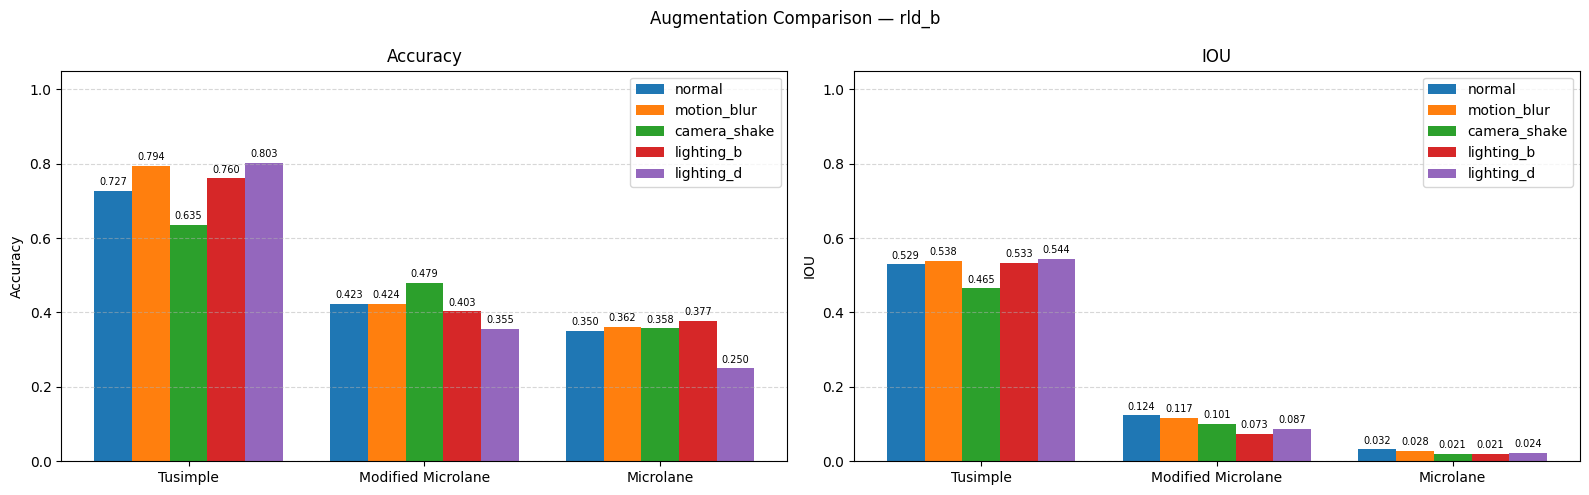

In [153]:
bar_graph(datasets=DATASETS, models=MODELS, augmentations=AUGMENTATIONS, records=total_records)

In [154]:
def draw_line_graph(records: list[pd.DataFrame]):

    COLORS = [
        "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
        "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990",
        "#dcbeff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    ]

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, record in enumerate(records):

        dataset = record.iloc[0]["dataset"]
        augmentation = record.iloc[0]["augmentation"]
        label = f"{dataset}.{augmentation}"

        cumulative_accuracy = record["accuracy"].expanding().mean()

        ax.plot(
            range(1, len(record) + 1),
            cumulative_accuracy,
            label=label,
            linewidth=1.8,
            color=COLORS[i % len(COLORS)],
        )

    ax.set_xlabel("Sample number", fontsize=12)
    ax.set_ylabel("Cumulative mean accuracy", fontsize=12)
    ax.set_ylim(0, 1)

    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, framealpha=0.7)
    ax.grid(True, linewidth=0.4, alpha=0.5)

    plt.tight_layout()
    plt.show()

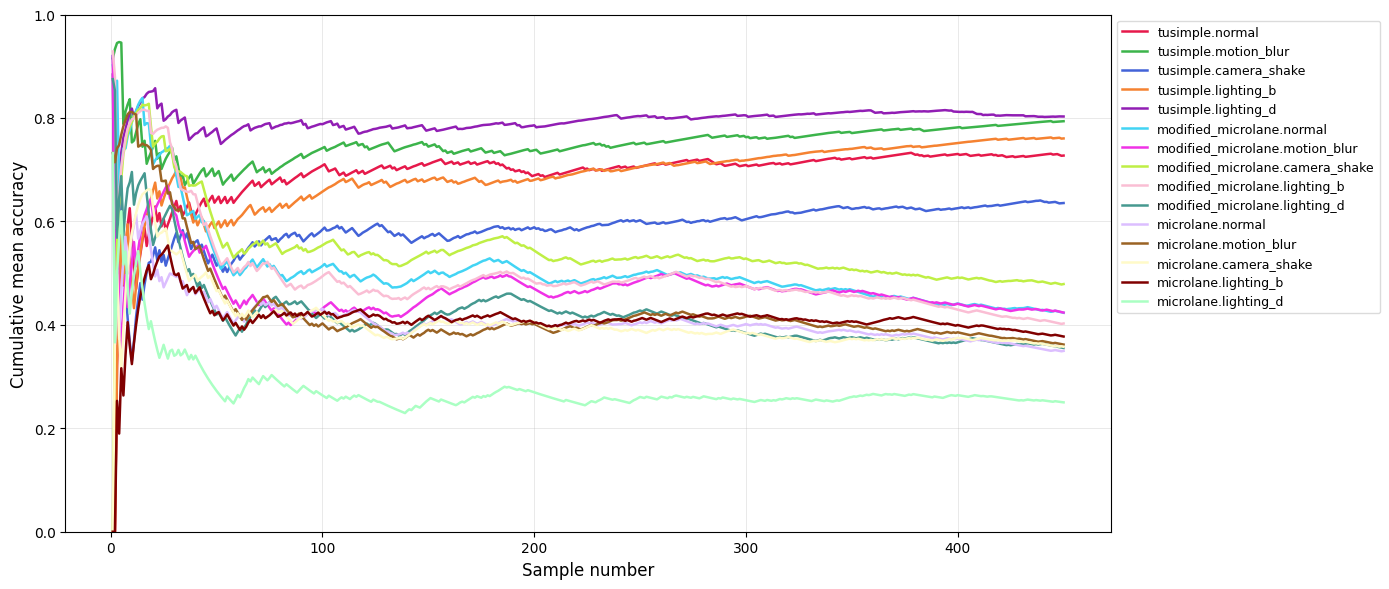

In [155]:
draw_line_graph(records=total_records)

In [156]:
LANE_COLORS = [(0,255,255), (0,255,0), (255,0,255), (255,165,0)]

def draw_lanes(img, lanes, h_samples, radius=5):
    out = img.copy()
    for i, lane in enumerate(lanes):
        color = LANE_COLORS[i % len(LANE_COLORS)]
        for x, y in zip(lane, h_samples):
            if x != -2:
                cv2.circle(out, (int(x), int(y)), radius, color, -1, cv2.LINE_AA)
    return out

def parse_path(path):
    parts = path.split("/")
    augmentation = parts[-3]  # normal / camera_shake / etc.
    model        = parts[-4]  # lanenet
    dataset      = parts[-5]  # tusimple
    return model, dataset, augmentation

In [157]:
def visualize(pred: Prediction, idx=-1, model="", dataset="", augmentation=""):

    sample = pred.samples[idx]

    original  = plt.imread(sample.image_path)

    augmented = sample.image

    gt_img    = draw_lanes(original, sample.lanes, sample.h_samples)

    pred_img  = draw_lanes(augmented, pred.lanes, pred.h_samples)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Model: {model}  |  Dataset: {dataset}  |  Aug: {augmentation}  |  {pred.run_time:.1f} ms", fontsize=9, color="gray")


    for ax, img, title in zip(axes, [gt_img, augmented, pred_img], ["Original", "Augmented", "Predictions"]):

        ax.imshow(img)

        ax.set_title(title)

        ax.axis("off")


    gt_legend   = [mpatches.Patch(color=tuple(c/255 for c in LANE_COLORS[i]), label=f"Lane {i}") for i in range(len(sample.lanes))] # type: ignore

    pred_legend = [mpatches.Patch(color=tuple(c/255 for c in LANE_COLORS[i]), label=f"Lane {i}") for i in range(len(pred.lanes))] # type: ignore


    axes[0].legend(handles=gt_legend,   loc="upper right", fontsize=8, framealpha=0.6)

    axes[2].legend(handles=pred_legend, loc="upper right", fontsize=8, framealpha=0.6)

    plt.tight_layout()
    
    plt.show()

In [158]:
def visualize_augmentations(sample: Sample, augmentor: Augmentor, augmentations, model="", dataset=""):

    sample_base = sample

    augmented_images = {
        aug: augmentor.apply_preset(
            copy.deepcopy(sample_base),
            aug
        ).image
        for aug in augmentations
    }

    titles = {
        "normal"       : "Normal",
        "motion_blur"  : "Motion Blur",
        "camera_shake" : "Camera Shake",
        "lighting_b"   : "Lighting (Bright)",
        "lighting_d"   : "Lighting (Dark)",
    }

    fig = plt.figure(figsize=(10, 4))
    fig.suptitle(f"Model: {model}  |  Dataset: {dataset}  |  Augmentation Modes", fontsize=9, color="gray")

    grid = fig.add_gridspec(2, 6, hspace=0.3, wspace=0.3)

    positions = [
        grid[0, 0:2],
        grid[0, 2:4],
        grid[0, 4:6],
        grid[1, 1:3],
        grid[1, 3:5],
    ]

    for pos, aug in zip(positions, augmentations):

        ax = fig.add_subplot(pos)

        ax.imshow(augmented_images[aug])

        ax.set_title(titles[aug], fontsize=10)

        ax.axis("off")

    plt.show()

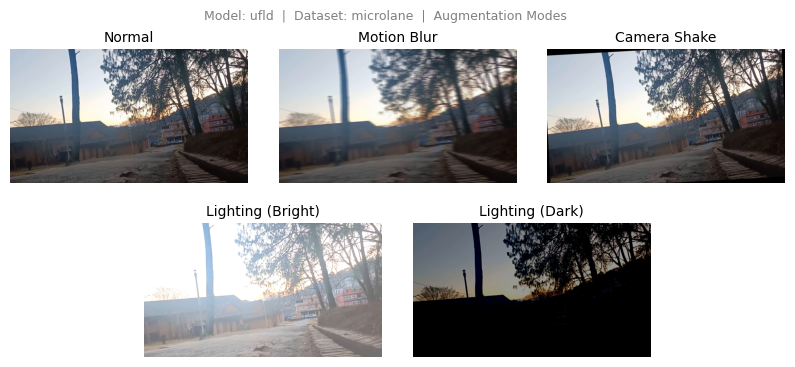

In [159]:

prediction_file  = "/home/suyog/desktop/projects/microlane/results/experiment/microlane/ufld/normal/experiment_2026-05-17_17-21-32/prediction.json"
prediction_index = 72

model, dataset, augmentation = parse_path(prediction_file)
auggmentor = Augmentor()

with open(prediction_file) as f:
    j = json.load(f)
    
j = j[prediction_index] 

pred = Prediction(
    lanes=j["lanes"],
    h_samples=j["h_samples"],
    run_time=j["run_time"],
    samples=[
         auggmentor.apply_preset(Sample(
            image_path=s["image_path"],
            image=read_image(s["image_path"]),
            lanes=s["lanes"],
            h_samples=s["h_samples"],
            dataset=s["dataset"],
            blur=s["blur"],
            lighting=s["lighting"],
            rotation=s["rotation"],
            zoom=s["zoom"],
            motion_blur=s["motion_blur"],
        ), augmentation)
        for s in j["samples"]
    ],
)

sample = pred.samples[-1]

# visualize(pred, model=model, dataset=dataset, augmentation=augmentation)

AUGMENTATIONS = ["normal", "motion_blur", "camera_shake", "lighting_b", "lighting_d"]

visualize_augmentations(sample, auggmentor, AUGMENTATIONS, model, dataset)

In [160]:
def calculate_for_radius_dataset(dataset: str, model: str, augmentations: list[str], records: list) -> dict:

    categories = {}

    for record in records:

        record_dataset      = record.iloc[0]["dataset"]

        record_augmentation = record.iloc[0]["augmentation"]

        record_model        = record.iloc[0]["model"]
        
        if record_dataset == dataset and record_model == model:
            
            if record_augmentation in augmentations:
            
                categories[record_augmentation] = calucalte_metrics(record)
            
            else: 
                raise ValueError("Wrong Input")

    return categories

In [161]:
def radar_chart(datasets: list[str], models: list[str], augmentations: list[str], records: list):

    FN_IDX = 3
    FP_IDX = 4

    FN_COLOR = "steelblue"
    FP_COLOR = "crimson"

    N = len(augmentations)
    
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close polygon
    
    for dataset in datasets:
        
        fig, axes = plt.subplots(
            1, len(models),
            figsize=(6 * len(models), 6),
            subplot_kw=dict(polar=True)
        )
        
        if len(models) == 1:
            axes = [axes]

        fig.suptitle(
            f"FN vs FP Radar — Dataset: {dataset.replace('_', ' ').title()}",
            fontsize=14, fontweight="bold", y=1.02
        )

        for ax, model in zip(axes, models):
                        
            metrics = calculate_for_radius_dataset(dataset, model, augmentations, records)

            fn_values = [metrics.get(aug, (0, 0, 0, 0, 0))[FN_IDX] for aug in AUGMENTATIONS]
            fp_values = [metrics.get(aug, (0, 0, 0, 0, 0))[FP_IDX] for aug in AUGMENTATIONS]

            # Close the polygons
            fn_values += fn_values[:1]
            fp_values += fp_values[:1]

            # Plot FN
            ax.plot(angles, fn_values, color=FN_COLOR, linewidth=2, linestyle="solid", label="FN")
            ax.fill(angles, fn_values, color=FN_COLOR, alpha=0.15)

            # Plot FP
            ax.plot(angles, fp_values, color=FP_COLOR, linewidth=2, linestyle="solid", label="FP")
            ax.fill(angles, fp_values, color=FP_COLOR, alpha=0.15)

            # Spoke labels
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(
                [a.replace("_", "\n") for a in AUGMENTATIONS],
                fontsize=8
            )

            ax.set_title(
                model.upper(),
                size=11, pad=15, fontweight="bold"
            )

            ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
            ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)
            
        plt.tight_layout()
        plt.show()

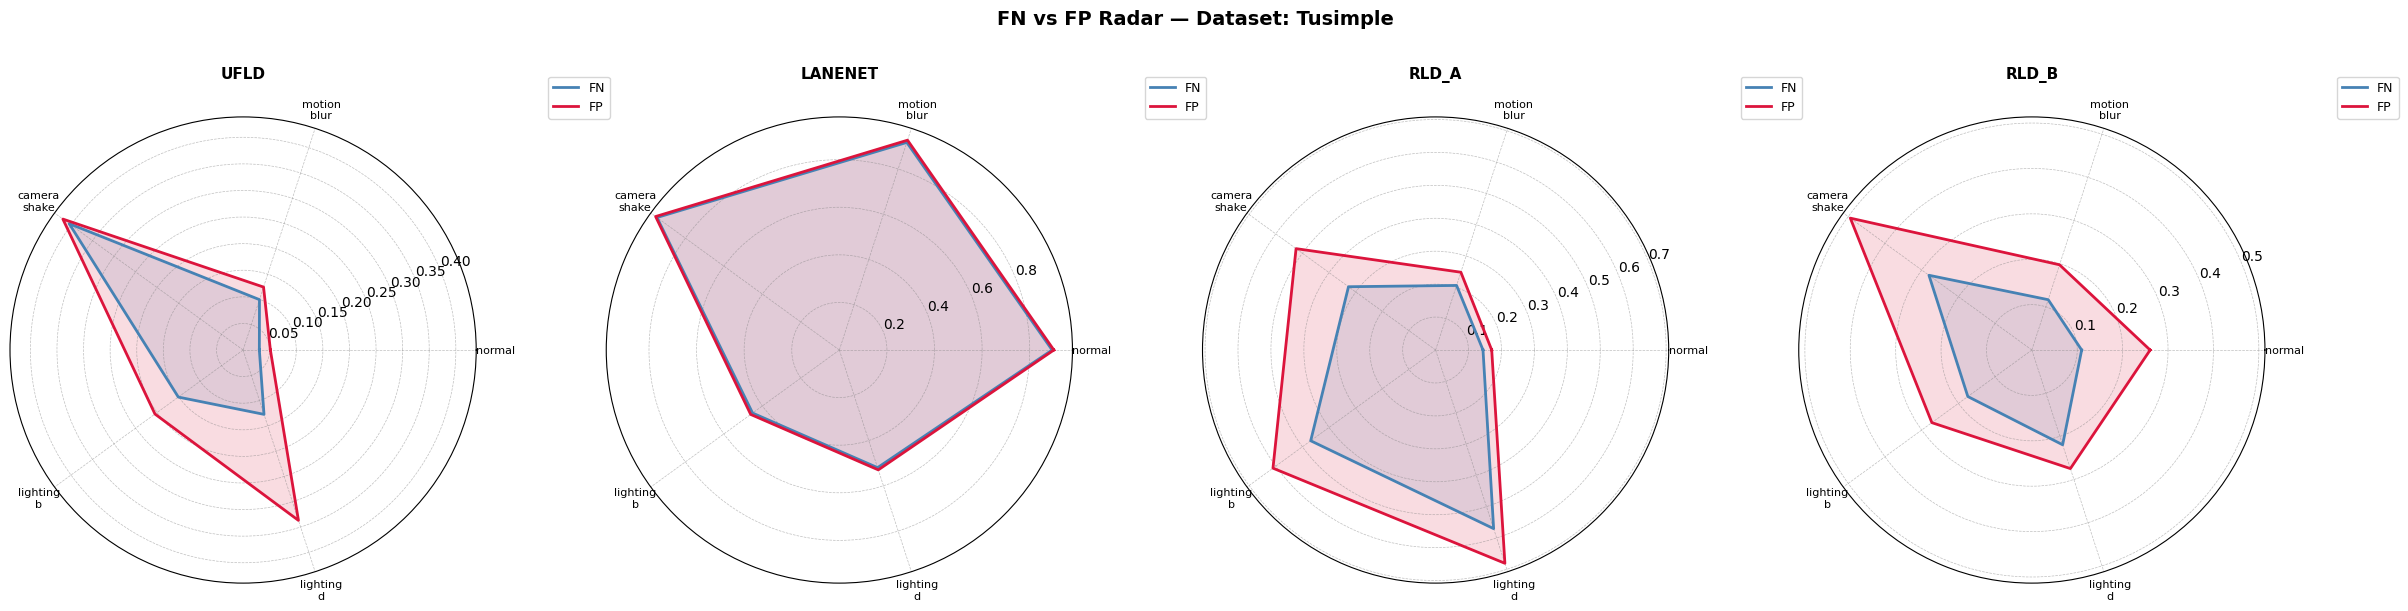

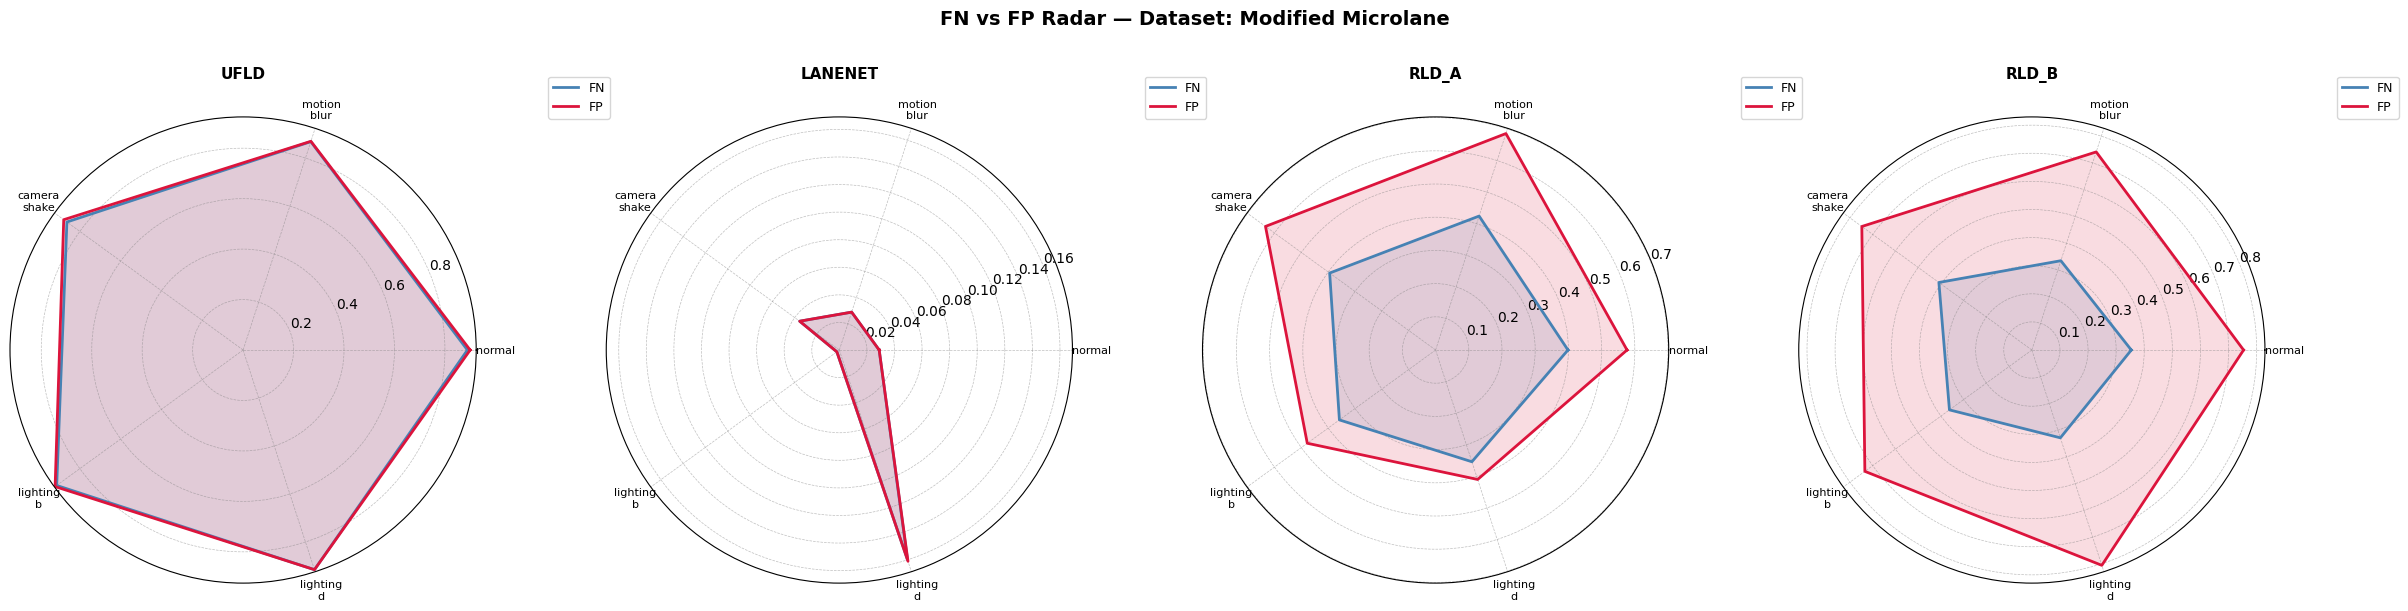

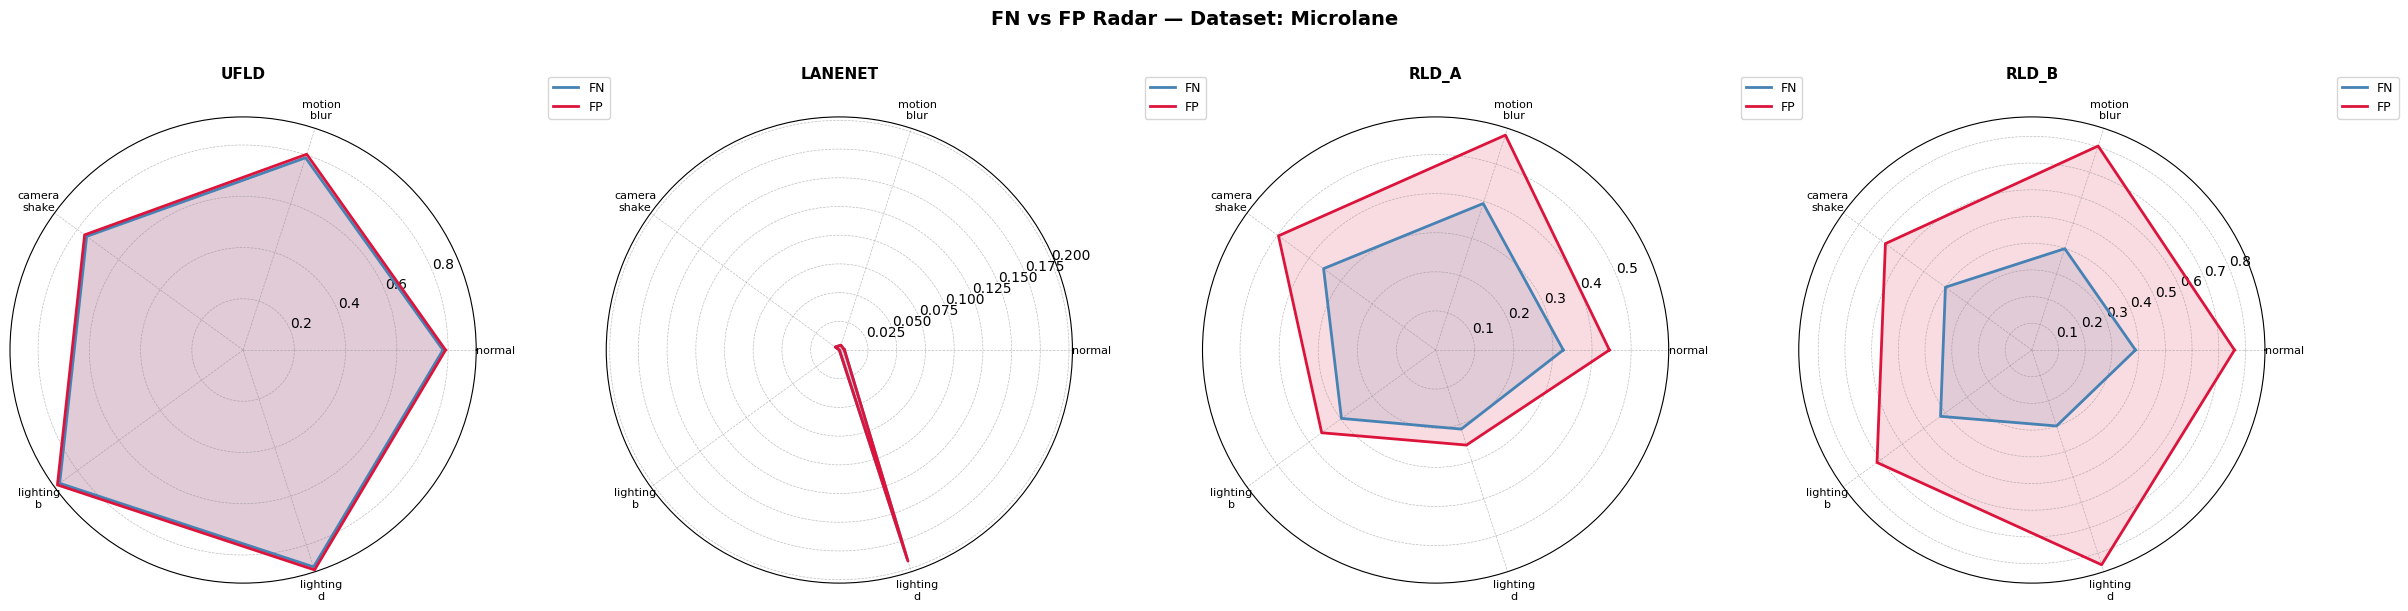

In [162]:
R_DATASETS     = ["tusimple", "modified_microlane", "microlane"]
R_MODELS       = ["ufld", "lanenet", "rld_a", "rld_b"]
R_AUGMENTATIONS = ["normal", "motion_blur", "camera_shake", "lighting_b", "lighting_d"]

total_records = collect_records(df, R_DATASETS, R_MODELS, R_AUGMENTATIONS)

radar_chart(R_DATASETS, R_MODELS, R_AUGMENTATIONS, total_records)